# 05 – Grundlastanalyse (Hausverbrauch)

Ziel: Die **Grundlast** (minimaler Hausverbrauch) schätzen,  
um aus der prognostizierten PV-Produktion die **verfügbare Überschuss-Energie** zu berechnen:

```
Verfügbare Energie = PV-Prognose − Grundlast
```

Fragen:
1. Wie hoch ist die typische Grundlast (nach Stunde × Wochentag)?
2. Gibt es saisonale Unterschiede?
3. Wie viel Überschuss bleibt typischerweise nach Grundlastabzug?

## 0 · Setup

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.preprocessing import load_pv_data
from src.data.splitting import time_series_split, split_summary
from src.features.feature_engineering import add_time_features

TARGET_PV   = "Solarproduktion"
TARGET_LOAD = "Hausverbrauch"
RESULTS_DIR = Path("../results/05_grundlast")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1 · Hausverbrauch laden & visualisieren

Zeitraum: 2022-02-07 – 2025-06-16
Datenpunkte: 113,896  (15-min-Auflösung)


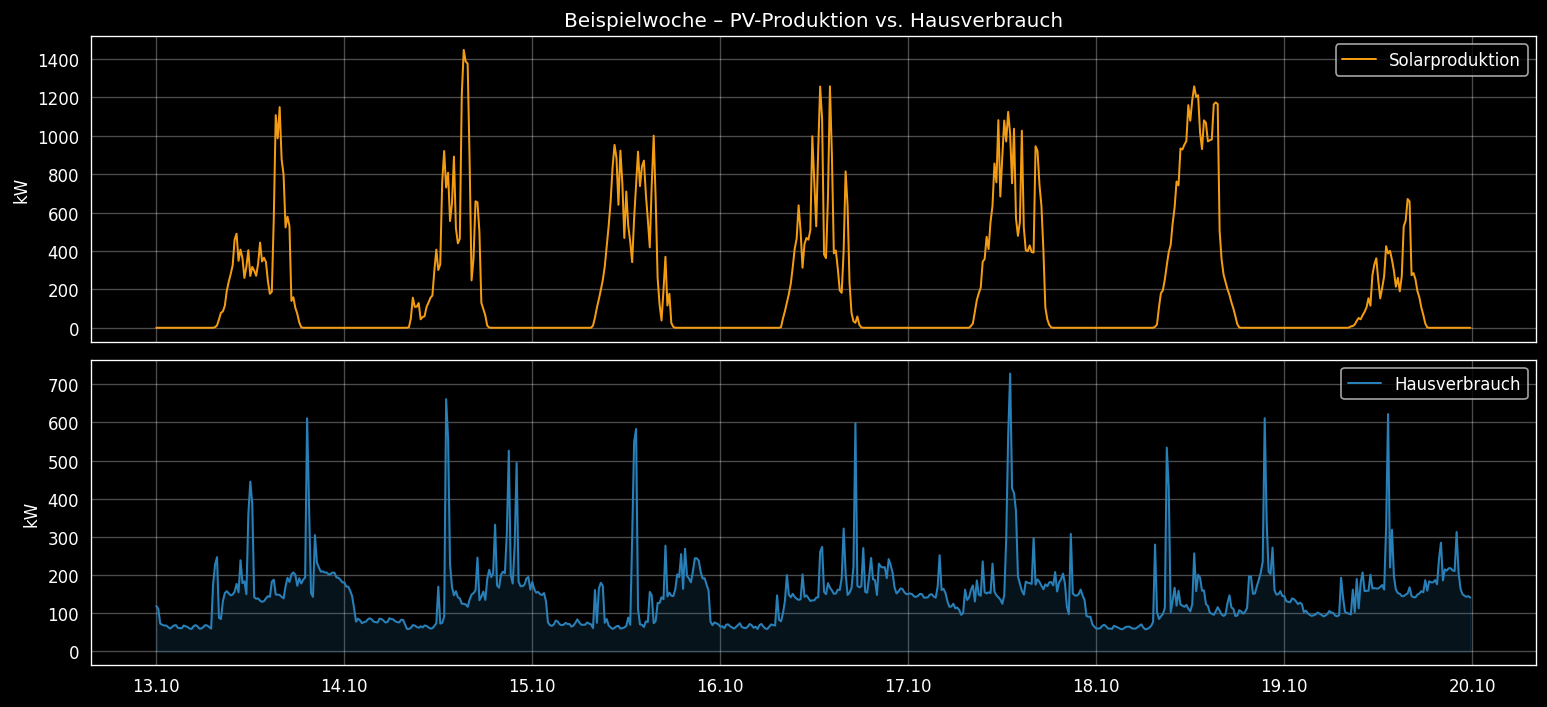


Hausverbrauch – Übersicht:
count    113896.00
mean        158.25
std         113.53
min           0.00
25%          81.00
50%         132.00
75%         194.00
max        2520.00
Name: Hausverbrauch, dtype: float64


In [2]:
df = load_pv_data()
df = add_time_features(df)
print(f"Zeitraum: {df['timestamp'].min().date()} – {df['timestamp'].max().date()}")
print(f"Datenpunkte: {len(df):,}  (15-min-Auflösung)")

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# 7-Tage-Beispiel
start = df["timestamp"].iloc[len(df) // 2].floor("D")
mask  = (df["timestamp"] >= start) & (df["timestamp"] < start + pd.Timedelta(days=7))
sub   = df[mask].set_index("timestamp")

axes[0].plot(sub.index, sub[TARGET_PV],   color="#f39c12", linewidth=1.2, label="Solarproduktion")
axes[0].set_ylabel("kW"); axes[0].legend()
axes[0].set_title("Beispielwoche – PV-Produktion vs. Hausverbrauch")

axes[1].plot(sub.index, sub[TARGET_LOAD], color="#2980b9", linewidth=1.2, label="Hausverbrauch")
axes[1].fill_between(sub.index, 0, sub[TARGET_LOAD], alpha=0.15, color="#2980b9")
axes[1].set_ylabel("kW"); axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
axes[1].xaxis.set_major_locator(mdates.DayLocator())

plt.tight_layout()
plt.show()

print(f"\nHausverbrauch – Übersicht:")
print(df[TARGET_LOAD].describe().round(2))

## 2 · Grundlast-Definition

> **Grundlast** = Verbrauch, der dauerhaft vorhanden ist (Kühlschrank, Standby, …).  
> Schätzmethode: **10. Perzentil** des Hausverbrauchs pro Stunde × Wochentag.  
> Robuster als Minimum (ignoriert kurzfristige Messfehler / Nullwerte).

In [3]:
# Grundlast = 10. Perzentil des Hausverbrauchs je Stunde × Wochentag
# → robuster gegenüber Ausreißern als Minimum

PERCENTILE = 10  # anpassbar

grundlast = (
    df.groupby(["hour", "day_of_week"])[TARGET_LOAD]
    .quantile(PERCENTILE / 100)
    .rename("grundlast")
    .reset_index()
)

print(f"Grundlast-Schätzer ({PERCENTILE}. Perzentil pro Stunde × Wochentag):")
print(f"  Median: {grundlast['grundlast'].median():.2f} kW")
print(f"  Min:    {grundlast['grundlast'].min():.2f} kW")
print(f"  Max:    {grundlast['grundlast'].max():.2f} kW")

Grundlast-Schätzer (10. Perzentil pro Stunde × Wochentag):
  Median: 73.95 kW
  Min:    63.00 kW
  Max:    122.00 kW


## 3 · Grundlast nach Stunde und Wochentag

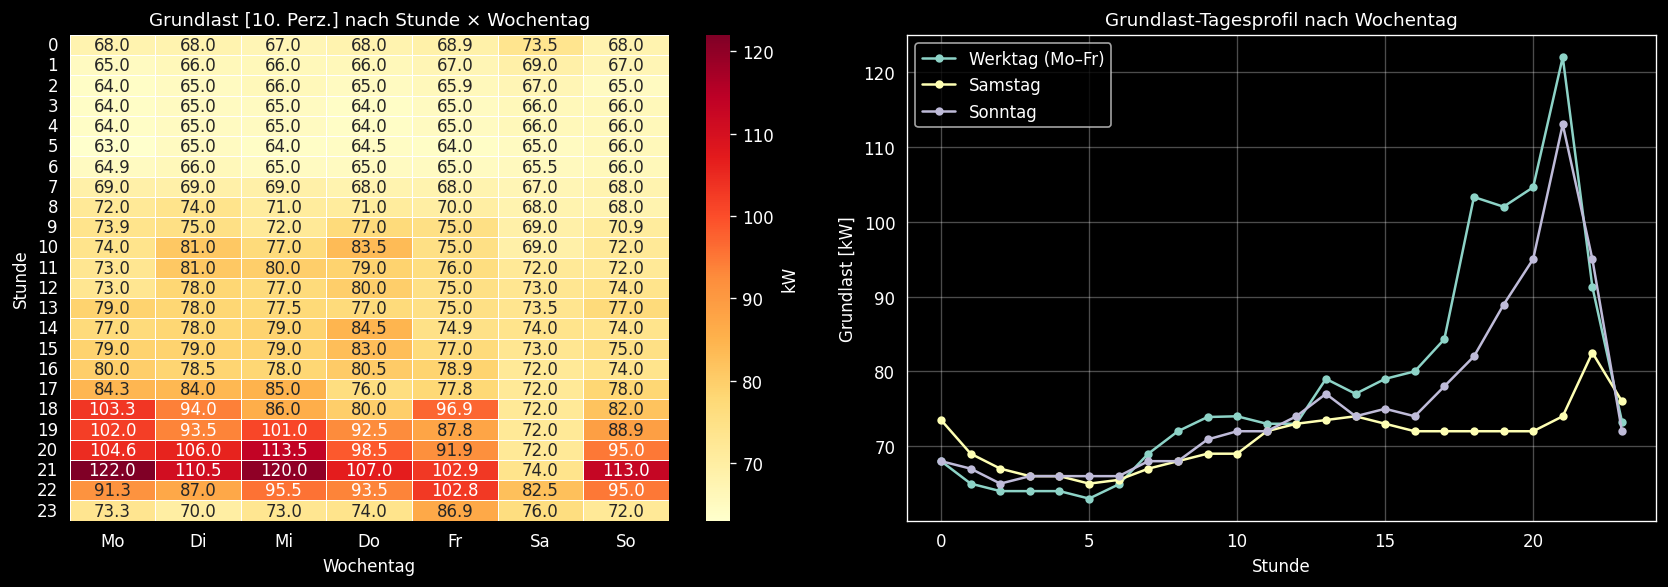

In [4]:
# Heatmap: Grundlast nach Stunde × Wochentag
pivot = grundlast.pivot(index="hour", columns="day_of_week", values="grundlast")
pivot.columns = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    pivot, ax=axes[0], cmap="YlOrRd", annot=True, fmt=".1f",
    linewidths=0.4, cbar_kws={"label": "kW"},
)
axes[0].set_title(f"Grundlast [{PERCENTILE}. Perz.] nach Stunde × Wochentag", fontsize=11)
axes[0].set_xlabel("Wochentag")
axes[0].set_ylabel("Stunde")

# Tagesprofil
for dow, name in [(0, "Werktag (Mo–Fr)"), (5, "Samstag"), (6, "Sonntag")]:
    sub = grundlast[grundlast["day_of_week"] == dow]
    axes[1].plot(sub["hour"], sub["grundlast"], marker="o", markersize=4, label=name)
axes[1].set_title("Grundlast-Tagesprofil nach Wochentag", fontsize=11)
axes[1].set_xlabel("Stunde")
axes[1].set_ylabel("Grundlast [kW]")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4 · Saisonaler Vergleich

/tmp/ipykernel_32710/2843487053.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_season, labels=season_order, patch_artist=True,


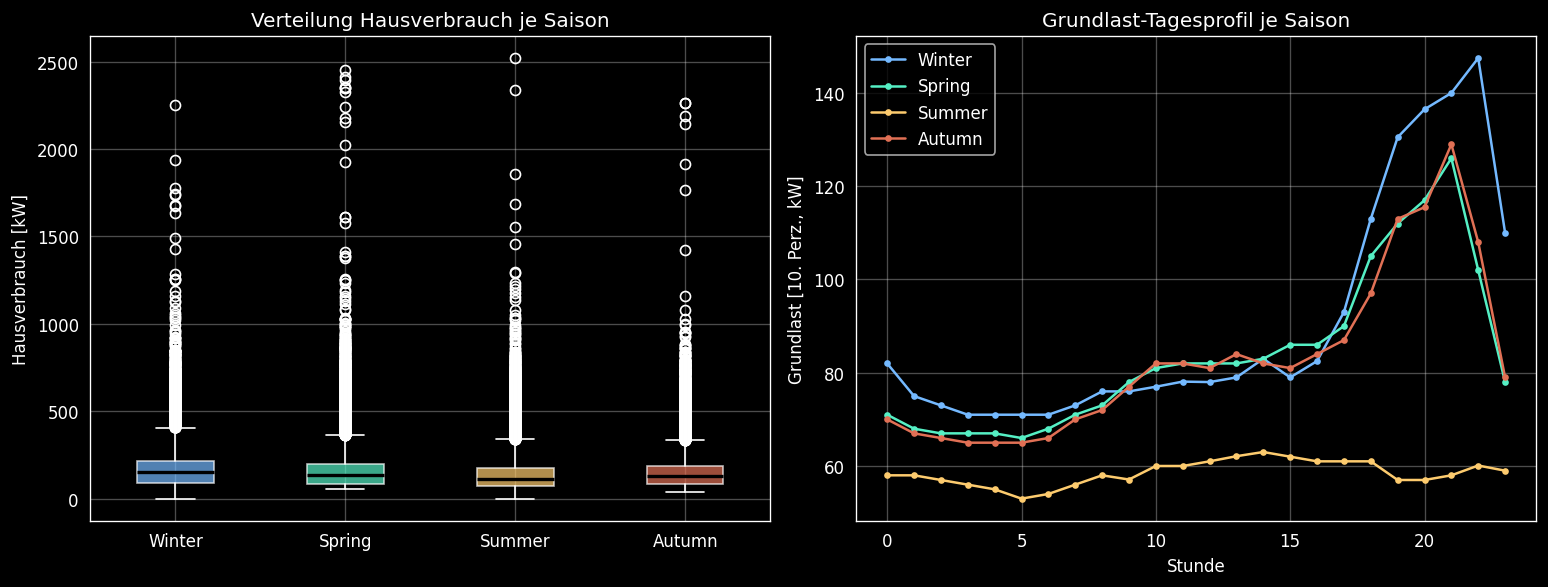

Grundlast-Statistik je Saison:
        Grundlast [kW]
season                
Winter            75.0
Spring            72.0
Summer            58.0
Autumn            71.0


In [5]:
# Saisonaler Vergleich der Grundlast

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Autumn", 10: "Autumn", 11: "Autumn"}

df["season"] = df["timestamp"].dt.month.map(season_map)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = {"Winter": "#74b9ff", "Spring": "#55efc4",
                 "Summer": "#fdcb6e", "Autumn": "#e17055"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box-Plot: Hausverbrauch je Saison
data_by_season = [df[df["season"] == s][TARGET_LOAD].dropna() for s in season_order]
bp = axes[0].boxplot(data_by_season, labels=season_order, patch_artist=True,
                     medianprops={"color": "black", "linewidth": 2})
for patch, season in zip(bp["boxes"], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.7)
axes[0].set_ylabel("Hausverbrauch [kW]")
axes[0].set_title("Verteilung Hausverbrauch je Saison")

# Tagesprofil je Saison (Median)
for season in season_order:
    profile = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_LOAD]
        .quantile(PERCENTILE / 100)
    )
    axes[1].plot(profile.index, profile.values, marker="o", markersize=3,
                 label=season, color=season_colors[season])
axes[1].set_xlabel("Stunde")
axes[1].set_ylabel(f"Grundlast [{PERCENTILE}. Perz., kW]")
axes[1].set_title("Grundlast-Tagesprofil je Saison")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Grundlast-Statistik je Saison:")
print(
    df.groupby("season")[TARGET_LOAD]
    .quantile(PERCENTILE / 100)
    .reindex(season_order)
    .round(2)
    .to_frame("Grundlast [kW]")
)

## 6 · Fazit & Grundlast-Schätzer speichern

In [7]:
# Grundlast-Lookup als JSON speichern (für spätere Modell-Integration)
out = {
    "method":     f"{PERCENTILE}. Perzentil pro (hour, day_of_week)",
    "percentile": PERCENTILE,
    "lookup":     {
        f"{int(h)}_{int(d)}": float(v)
        for (h, d), v in gl_lookup.items()
    },
    "stats": {
        "median_kw": float(gl_lookup.median()),
        "min_kw":    float(gl_lookup.min()),
        "max_kw":    float(gl_lookup.max()),
    },
}

path = RESULTS_DIR / "grundlast_lookup.json"
with open(path, "w") as f:
    json.dump(out, f, indent=2)
print(f"Gespeichert: {path}")

print(f"\nFazit:")
print(f"  Typische Grundlast: {gl_lookup.median():.2f} kW")
print(f"  Spanne:             {gl_lookup.min():.2f} – {gl_lookup.max():.2f} kW")
print(f"  Val-Überschuss:     {(val_avail > 0).mean():.1%} der Zeitschritte positiv")

Gespeichert: ../results/05_grundlast/grundlast_lookup.json

Fazit:
  Typische Grundlast: 73.55 kW
  Spanne:             63.00 – 123.00 kW
  Val-Überschuss:     42.7% der Zeitschritte positiv
